# E3SM and CESM-SMYLE Seasonal Modes-of-Variability Analysis

Analyze the official PMP extra-tropical modes (`NAM`, `NAO`, `SAM`, `PNA`,
`NPO`, `PDO`, and `NPGO`) and the ESP-Lab extensions (`EA`, `SCA`, and
`AMO`). Set `selected_mode` in the control panel. NAO includes station-
and EOF-based skill; all other modes use the common-basis EOF index.

This revised notebook keeps the scientific workflow in the notebook and uses
one helper module, `esp_lab.utils.mov_utils`, for reusable MOV map, plotting,
I/O, and skill-metric utilities.


In [92]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import os
import re
import uuid
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from esp_lab import stats
from esp_lab.utils import mov_utils as mov

FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
print("xarray:", xr.__version__)
print("map utilities:", getattr(mov, "__file__", "module object"))
print("cartopy available:", mov.has_cartopy())


xarray: 2026.4.0
map utilities: /global/u2/z/zhan391/code/ESP-Lab/esp_lab/utils/mov_utils.py
cartopy available: True


## User Control Panel


In [94]:
# Select one mode produced by 0_run_modes_of_variability_processing.ipynb.

from pathlib import Path
import numpy as np

official_pmp_modes = ("NAM", "NAO", "SAM", "PNA", "NPO", "PDO", "NPGO")
extension_modes = ("EA", "SCA", "AMO", "PSA1", "PSA2")
supported_modes = official_pmp_modes + extension_modes

selected_mode = "SCA" #"EA" #"NPGO" #"NAO" #"NPO"
selected_mode = selected_mode.upper().strip()

if selected_mode not in supported_modes:
    raise ValueError(
        f"selected_mode must be one of {supported_modes}, got {selected_mode!r}"
    )

analysis_outdir = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes_variability")
manifest_file = analysis_outdir / "modes_manifest.json"
index_cache_dir = analysis_outdir / "modes" / selected_mode.lower() / "indices"
skill_cache_dir = analysis_outdir / "skill" / "fixed_obs_projection"
table_outdir = analysis_outdir / "tables"

models = ("E3SM", "SMYLE")
init_months = [5, 11]

climy0 = 1980
climy1 = 2010
seasonal_nlead = 7
skill_detrend = False
force_recompute_skill = False
write_summary_tables = True

analysis_methods = ["eof"]
if selected_mode == "NAO":
    analysis_methods = ["station", "eof"]


# ---------------------------------------------------------------------
# Mode-aware EOF-pattern map configuration
# ---------------------------------------------------------------------
# label_strategy:
#   "cartopy" : normal Cartopy longitude/latitude labels
#   "pacific" : manual Pacific labels, e.g., 120E, 150E, 180, 150W
#   "polar"   : polar-style labels; no regular Cartopy x/y labels
# ---------------------------------------------------------------------

BASE_EOF_PATTERN_SETTINGS = {
    # General figure layout
    "figsize_width": 14.5,
    "figsize_row_height": 2.75,
    "pattern_years": (1, 2),
    "pattern_seasons": ("DJF", "MAM", "JJA", "SON"),
    "preferred_init_by_season": {
        "DJF": 11,
        "MAM": 11,
        "JJA": 5,
        "SON": 5,
    },

    # Main title / column headers / panel titles
    "suptitle_scale": 1.00,
    "column_header_scale": 0.95,
    "panel_title_scale": 0.72,
    "panel_title_pad": 3,
    "panel_title_linespacing": 1.10,
    "year_section_title_scale": 1.00,

    # Metric box
    "rmse_decimals": 2,
    "pcc_decimals": 2,
    "metric_box_x": 0.03,
    "metric_box_y": 0.045,
    "metric_box_font_scale": 0.62,
    "metric_box_alpha": 0.72,
    "metric_box_pad": 0.16,
    "metric_box_linewidth": 0.45,
    "metric_box_zorder": 10,

    # Axis/colorbar labels
    "axis_label_scale": 0.90,
    "tick_label_scale": 0.58,
    "colorbar_label_scale": 0.78,
    "colorbar_tick_scale": 0.66,
    "colorbar_shrink": 0.80,
    "colorbar_pad": 0.035,
    "colorbar_fraction": 0.030,

    # Stippling
    "stipple_stride": 2,
    "stipple_size": 9,
    "stipple_color": "black",
    "stipple_alpha": 0.50,
    "stipple_zorder": 4,

    # Filled contours and contour lines
    "levels": np.arange(-3.0, 3.01, 0.5),
    "draw_contour_lines": True,
    "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    "contour_line_color": "0.20",
    "contour_linewidth": 0.45,
    "contour_line_alpha": 0.70,

    # Gridline style
    "grid_alpha": 0.45,
    "grid_linewidth": 0.8,
    "grid_linestyle": "--",
    "grid_color": "0.55",
    "grid_rotate_labels": False,

    # Label visibility defaults
    "label_strategy": "cartopy",
    "map_draw_labels": True,
    "map_label_scale": 0.55,
    "draw_left_labels": True,
    "draw_bottom_labels": True,
    "draw_top_labels": False,
    "draw_right_labels": False,
    "label_left_column_only": True,
    "label_bottom_row_only": True,

    # Default tick locations
    "longitude_ticks": np.arange(-180, 181, 30),
    "latitude_ticks": np.arange(-90, 91, 20),
    "longitude_ticklabels": None,
    "latitude_ticklabels": None,

    # Manual label offsets for projected maps
    "manual_lon_label_offset": 1.5,
    "manual_lat_label_offset": 1.5,

    # Polar-map behavior
    "polar_circular_boundary": True,
    "polar_draw_regular_labels": False,
    "polar_longitude_label_offset": 2.5,
    "polar_longitude_ticks": np.arange(-180, 181, 60),

    # Section spacing
    "top_section_gap_ratio": 0.015,
    "year_section_header_ratio": 0.58,
    "year_section_gap_ratio": 0.16,

    # Subplot layout
    "subplot_left": 0.070,
    "subplot_right": 0.965,
    "subplot_bottom": 0.145,
    "subplot_top": 0.890,
    "subplot_wspace": 0.080,
    "subplot_hspace": 0.300,

    # Map features
    "use_cartopy": True,
    "coastline_linewidth": 0.45,
    "global_land_facecolor": "0.18",
    "global_land_edgecolor": "0.05",
    "global_land_linewidth": 0.25,
    "global_land_zorder": 4,
    "global_coastline_color": "0.05",
    "global_coastline_linewidth": 0.35,
    "global_coastline_zorder": 5,
}


MODE_LAYOUT_CONFIG = {
    "NAM": {
        "figsize_width": 13.5,
        "figsize_row_height": 2.95,
        "subplot_left": 0.045,
        "subplot_right": 0.970,
        "subplot_bottom": 0.145,
        "subplot_top": 0.875,
        "subplot_wspace": 0.045,
        "subplot_hspace": 0.240,
        "map_label_scale": 0.50,
    },
    "SAM": {
        "figsize_width": 13.5,
        "figsize_row_height": 2.95,
        "subplot_left": 0.045,
        "subplot_right": 0.970,
        "subplot_bottom": 0.145,
        "subplot_top": 0.875,
        "subplot_wspace": 0.045,
        "subplot_hspace": 0.240,
        "map_label_scale": 0.50,
    },
    "NAO": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.50,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.08,
        "subplot_hspace": 0.22,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 0,
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "EA": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.50,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.08,
        "subplot_hspace": 0.22,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 0,
    },
    "SCA": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.50,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.08,
        "subplot_hspace": 0.22,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 0,
    },
    "PNA": {
        "figsize_width": 14.8,
        "figsize_row_height": 2.75,
        "subplot_left": 0.082,
        "subplot_right": 0.965,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.090,
        "subplot_hspace": 0.300,
        "map_label_scale": 0.5,
    },
    "NPO": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.50,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.08,
        "subplot_hspace": 0.22,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 0,
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "NPGO": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.50,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.08,
        "subplot_hspace": 0.22,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 0,
        "levels": np.arange(-1.0, 1.01, 0.2),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-1.0, 1.01, 0.2),    },
    "PDO": {
        "figsize_width": 15.0,
        "figsize_row_height": 2.80,
        "subplot_left": 0.065,
        "subplot_right": 0.965,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.070,
        "subplot_hspace": 0.300,
        "map_label_scale": 0.50,
    },
    "AMO": {
        "figsize_width": 15.0,
        "figsize_row_height": 2.80,
        "subplot_left": 0.065,
        "subplot_right": 0.965,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.070,
        "subplot_hspace": 0.300,
        "map_label_scale": 0.50,
    },
    "PSA1": {
        "figsize_width": 13.8,
        "figsize_row_height": 2.90,
        "subplot_left": 0.050,
        "subplot_right": 0.970,
        "subplot_bottom": 0.145,
        "subplot_top": 0.875,
        "subplot_wspace": 0.050,
        "subplot_hspace": 0.250,
        "map_label_scale": 0.50,
    },
    "PSA2": {
        "figsize_width": 13.8,
        "figsize_row_height": 2.90,
        "subplot_left": 0.050,
        "subplot_right": 0.970,
        "subplot_bottom": 0.145,
        "subplot_top": 0.875,
        "subplot_wspace": 0.050,
        "subplot_hspace": 0.250,
        "map_label_scale": 0.50,
    },
}


PACIFIC_LONGITUDE_TICKS = np.array([120, 150, 180, -150, -120])
PACIFIC_LONGITUDE_LABELS = ["120°E", "150°E", "180°", "150°W", "120°W"]
NORTH_PACIFIC_LATITUDE_TICKS = np.array([10, 20, 30, 40, 50, 60, 70])
NORTH_PACIFIC_LATITUDE_LABELS = ["10°N", "20°N", "30°N", "40°N", "50°N", "60°N", "70°N"]

ATLANTIC_LONGITUDE_TICKS = np.array([-90, -60, -30, 0, 30])
ATLANTIC_LATITUDE_TICKS = np.array([20, 30, 40, 50, 60, 70, 80])

GLOBAL_LONGITUDE_TICKS = np.arange(-180, 181, 60)
GLOBAL_LATITUDE_TICKS = np.arange(-60, 61, 30)

ALBERS_PROJECTION_BY_MODE = {
    "NAO":  {"central_longitude": -30,  "central_latitude": 50, "standard_parallels": (30, 70)},
    "EA":   {"central_longitude": -20,  "central_latitude": 50, "standard_parallels": (30, 70)},
    "SCA":  {"central_longitude": -20,  "central_latitude": 50, "standard_parallels": (35, 70)},
    "NPO":  {"central_longitude": 180,  "central_latitude": 40, "standard_parallels": (20, 60)},
    "NPGO": {"central_longitude": 180,  "central_latitude": 45, "standard_parallels": (20, 60)},
}

MODE_MAP_LABEL_CONFIG = {
    "NAM": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.arange(20, 91, 10),
        "polar_longitude_ticks": np.arange(-180, 181, 60),
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "grid_rotate_labels": False,
    },
    "SAM": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.arange(-90, -19, 10),
        "polar_longitude_ticks": np.arange(-180, 181, 60),
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "grid_rotate_labels": False,
    },
    "NAO": {
        "label_strategy": "cartopy",
        "longitude_ticks": ATLANTIC_LONGITUDE_TICKS,
        "latitude_ticks": ATLANTIC_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "EA": {
        "label_strategy": "cartopy",
        "longitude_ticks": ATLANTIC_LONGITUDE_TICKS,
        "latitude_ticks": ATLANTIC_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "SCA": {
        "label_strategy": "cartopy",
        "longitude_ticks": ATLANTIC_LONGITUDE_TICKS,
        "latitude_ticks": ATLANTIC_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "PNA": {
        "label_strategy": "cartopy",
        "longitude_ticks": PACIFIC_LONGITUDE_TICKS,
        "longitude_ticklabels": PACIFIC_LONGITUDE_LABELS,
        "latitude_ticks": NORTH_PACIFIC_LATITUDE_TICKS,
        "latitude_ticklabels": NORTH_PACIFIC_LATITUDE_LABELS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "label_left_column_only": True,
        "label_bottom_row_only": True,
        "grid_rotate_labels": False,
    },
    "NPO": {
        "label_strategy": "cartopy",
        "longitude_ticks": PACIFIC_LONGITUDE_TICKS,
        "longitude_ticklabels": PACIFIC_LONGITUDE_LABELS,
        "latitude_ticks": NORTH_PACIFIC_LATITUDE_TICKS,
        "latitude_ticklabels": NORTH_PACIFIC_LATITUDE_LABELS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "label_left_column_only": True,
        "label_bottom_row_only": True,
        "grid_rotate_labels": False,
    },
    "NPGO": {
        "label_strategy": "cartopy",
        "longitude_ticks": PACIFIC_LONGITUDE_TICKS,
        "longitude_ticklabels": PACIFIC_LONGITUDE_LABELS,
        "latitude_ticks": NORTH_PACIFIC_LATITUDE_TICKS,
        "latitude_ticklabels": NORTH_PACIFIC_LATITUDE_LABELS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "PDO": {
        "label_strategy": "cartopy",
        "longitude_ticks": GLOBAL_LONGITUDE_TICKS,
        "latitude_ticks": GLOBAL_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "AMO": {
        "label_strategy": "cartopy",
        "longitude_ticks": GLOBAL_LONGITUDE_TICKS,
        "latitude_ticks": GLOBAL_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "PSA1": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.arange(-90, -19, 10),
        "polar_longitude_ticks": np.arange(-180, 181, 60),
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "grid_rotate_labels": False,
    },
    "PSA2": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.arange(-90, -19, 10),
        "polar_longitude_ticks": np.arange(-180, 181, 60),
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "grid_rotate_labels": False,
    },
}

def get_eof_pattern_settings(mode, overrides=None):
    """Return mode-aware plotting settings for EOF pattern maps."""
    mode = mode.upper().strip()

    settings = dict(BASE_EOF_PATTERN_SETTINGS)
    settings.update(MODE_LAYOUT_CONFIG.get(mode, {}))
    settings.update(MODE_MAP_LABEL_CONFIG.get(mode, {}))

    if overrides:
        settings.update(overrides)

    return settings


FIGURE_SETUP = {
    "common": {
        "fontsize": 18,
        "dpi": 300,
    },
    "skill": {
        "figsize_per_column": (9, 10),
        "suptitle_scale": 1.00,
        "suptitle_linespacing": 1.15,
        "panel_title_scale": 1.00,
        "axis_label_scale": 1.00,
        "tick_label_scale": 0.95,
        "legend_font_scale": 0.90,
        "title_pad": 6,
        "marker_size": 12,
        "significance_zorder": 5,
        "grid_alpha": 0.45,
        "grid_linewidth": 0.5,
        "reference_linewidth": 2.0,
        "legend_init_linewidth": 2.2,
        "legend_columns": 2,
        "legend_handle_length": 2.4,
        "legend_column_spacing": 1.2,
        "legend_label_spacing": 0.35,
        "init_colors": {5: "green", 11: "black"},
        "init_labels": {5: "MAY init", 11: "NOV init"},
        "model_linestyles": {"SMYLE": "-", "E3SM": ":"},
        "model_linewidths": {"SMYLE": 2.2, "E3SM": 2.5},
        "season_markers": {1: "D", 4: "o", 7: "s", 10: "P"},
        "season_labels": {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"},
    },
    "eof_patterns": get_eof_pattern_settings(selected_mode),
}

fontz = FIGURE_SETUP["common"]["fontsize"]
figure_dpi = FIGURE_SETUP["common"]["dpi"]
eof_settings = FIGURE_SETUP["eof_patterns"]

# ---------------------------------------------------------
# Derived font sizes: use these variables in plotting cells.
# ---------------------------------------------------------
suptitle_fontsize = fontz * eof_settings.get("suptitle_scale", 1.00)
column_header_fontsize = fontz * eof_settings.get("column_header_scale", 0.95)
panel_title_fontsize = fontz * eof_settings.get("panel_title_scale", 0.72)
metric_box_fontsize = fontz * eof_settings.get("metric_box_font_scale", 0.62)
map_label_fontsize = fontz * eof_settings.get("map_label_scale", 0.55)
colorbar_label_fontsize = fontz * eof_settings.get("colorbar_label_scale", 0.78)
colorbar_tick_fontsize = fontz * eof_settings.get("colorbar_tick_scale", 0.66)

BASE_METRIC_SPECS = [
    ("corr", "ACC", (-0.5, 0.9)),
    ("rmse", "Normalized RMSE", (0.9, 1.2)),
]

MODE_METRIC_SPECS = {
    "NAM": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "NAO": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.4)),
    ],
    "SAM": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "PNA": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "NPO": [
        ("corr", "ACC", (-0.4, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "PDO": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.4)),
    ],
    "NPGO": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.4)),
    ],
    "AMO": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.4)),
    ],
    "PSA1": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "PSA2": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
}

method_titles = {
    "station": "Station-based",
    "eof": "Projected EOF",
}

metric_specs = MODE_METRIC_SPECS.get(selected_mode, BASE_METRIC_SPECS)

lead_month_ticks = [1, 4, 7, 10, 13, 16, 19]
lead_month_ticklabels = [str(lead) for lead in lead_month_ticks]
lead_month_limits = (0, 20)

lead_convention_note = (
    "Seasonal products use internal L=3,6,...; plots show lead month as L-2. "
    "Marker shape gives verifying season."
)

significance_level = 0.1

print("selected mode:", selected_mode)
print("processed products:", index_cache_dir)
print("anomaly/drift climatology:", climy0, climy1)
print("analysis methods:", analysis_methods)
print("lead convention:", lead_convention_note)
print("EOF pattern layout profile:", selected_mode)
print(
    "font sizes:",
    {
        "suptitle": suptitle_fontsize,
        "column_header": column_header_fontsize,
        "panel_title": panel_title_fontsize,
        "metric_box": metric_box_fontsize,
        "map_label": map_label_fontsize,
        "colorbar_label": colorbar_label_fontsize,
        "colorbar_tick": colorbar_tick_fontsize,
    },
)
print(
    "subplot layout:",
    {
        key: eof_settings[key]
        for key in (
            "figsize_width",
            "figsize_row_height",
            "subplot_left",
            "subplot_right",
            "subplot_bottom",
            "subplot_top",
            "subplot_wspace",
            "subplot_hspace",
            "map_label_scale",
        )
    },
)
print(
    "map label config:",
    {
        key: eof_settings.get(key)
        for key in (
            "label_strategy",
            "longitude_ticks",
            "longitude_ticklabels",
            "latitude_ticks",
            "latitude_ticklabels",
            "draw_left_labels",
            "draw_bottom_labels",
            "grid_rotate_labels",
        )
    },
)

selected mode: SCA
processed products: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes_variability/modes/sca/indices
anomaly/drift climatology: 1980 2010
analysis methods: ['eof']
lead convention: Seasonal products use internal L=3,6,...; plots show lead month as L-2. Marker shape gives verifying season.
EOF pattern layout profile: SCA
font sizes: {'suptitle': 16.2, 'column_header': 15.299999999999999, 'panel_title': 12.6, 'metric_box': 11.16, 'map_label': 13.5, 'colorbar_label': 14.040000000000001, 'colorbar_tick': 11.88}
subplot layout: {'figsize_width': 10.0, 'figsize_row_height': 2.5, 'subplot_left': 0.08, 'subplot_right': 0.94, 'subplot_bottom': 0.15, 'subplot_top': 0.89, 'subplot_wspace': 0.08, 'subplot_hspace': 0.22, 'map_label_scale': 0.75}
map label config: {'label_strategy': 'cartopy', 'longitude_ticks': array([-90, -60, -30,   0,  30]), 'longitude_ticklabels': None, 'latitude_ticks': array([20, 30, 40, 50, 60, 70, 80]), 'latitude_ticklabels': None, 'draw_left_labels': True, 'dra

## Validate Processed Products


In [95]:
if manifest_file.exists():
    manifest = json.loads(manifest_file.read_text())
    if manifest.get("eof", {}).get("package") != "pcmdi_metrics":
        raise ValueError("Processed products do not use the PCMDI EOF workflow.")
    if manifest.get("climatology") != [climy0, climy1]:
        raise ValueError(
            f"Notebook climatology {[climy0, climy1]} does not match "
            f"processed data {manifest.get('climatology')}."
        )
    verification_year0, verification_year1 = manifest.get("years", [None, None])
    eof_reference_year0, eof_reference_year1 = manifest.get("eof", {}).get("reference_years", [None, None])
    if verification_year0 is None or verification_year1 is None:
        raise ValueError("Manifest is missing processing/verification years.")
    print("Validated shared manifest settings:", manifest_file)
else:
    manifest = None
    verification_year0, verification_year1 = None, None
    eof_reference_year0, eof_reference_year1 = None, None
    print("Manifest not available; validating mode files directly.")

reference_files = sorted(index_cache_dir.glob("*_reference.nc"))
if len(reference_files) != 1:
    raise FileNotFoundError(
        f"Expected one reference file in {index_cache_dir}, found {reference_files}"
    )
obs_index_file = reference_files[0]
required_files = [obs_index_file] + [
    index_cache_dir
    / f"{model.lower()}_init{init_month:02d}_{selected_mode.lower()}.nc"
    for model in models
    for init_month in init_months
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing processed {selected_mode} files: {missing_files}"
    )

print("Reference:", obs_index_file.name)
print("Validated", len(required_files), selected_mode, "files")
print("verification years:", verification_year0, verification_year1)
print("EOF reference years:", eof_reference_year0, eof_reference_year1)


Validated shared manifest settings: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes_variability/modes_manifest.json
Reference: era5_sca_reference.nc
Validated 5 SCA files
verification years: 1980 2018
EOF reference years: 1980 2018


## Skill Helper


In [96]:
def skill_dataset(model_index, model_time, obs_index):
    nleads = min(seasonal_nlead, model_index.sizes["L"])
    return stats.compute_skill_seasonal(
        model_index,
        model_time,
        obs_index,
        climy0,
        climy1,
        nleadavg=1,
        nleads=nleads,
        resamp=0,
        detrend=skill_detrend,
        is_anomaly=True,
    ).load()


## Load Processed Model Products


In [97]:
model_index = {
    model: {method: {} for method in analysis_methods}
    for model in models
}
model_time = {model: {} for model in models}
model_datasets = {model: {} for model in models}
model_provenance = {model: {} for model in models}

required_base_variables = {
    "mode_index",
    "mode_pattern",
    "mode_variance_fraction",
    "target_month",
    "valid_time",
}
optional_pattern_variables = {
    "mode_index_conventional",
    "mode_regression_significant",
    "mode_pattern_bootstrap_lower",
    "mode_pattern_bootstrap_upper",
    "mode_pattern_rmse_reference",
    "mode_pattern_pcc_reference",
}

for model in models:
    source_name = model.lower()
    for init_month in init_months:
        index_file = (
            index_cache_dir
            / f"{source_name}_init{init_month:02d}_{selected_mode.lower()}.nc"
        )
        dataset = xr.open_dataset(index_file).load()
        missing = required_base_variables - set(dataset.data_vars)
        if missing:
            raise ValueError(f"{index_file.name} is missing {sorted(missing)}")
        model_datasets[model][init_month] = dataset
        model_provenance[model][init_month] = dict(dataset.attrs)
        model_index[model]["eof"][init_month] = dataset["mode_index"]
        if "station" in analysis_methods:
            if "nao_station" not in dataset:
                raise ValueError(f"{index_file.name} lacks nao_station")
            model_index[model]["station"][init_month] = dataset["nao_station"]
        model_time[model][init_month] = dataset["valid_time"]
        available_optional = sorted(
            optional_pattern_variables & set(dataset.data_vars)
        )
        print(
            model,
            init_month,
            dataset.sizes,
            "optional diagnostics:",
            available_optional,
        )


E3SM 5 Frozen({'Y': 39, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53}) optional diagnostics: ['mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant']
E3SM 11 Frozen({'Y': 39, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53}) optional diagnostics: ['mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant']
SMYLE 5 Frozen({'Y': 39, 'L': 7, 'M': 20, 'lat': 25, 'lon': 53}) optional diagnostics: ['mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant']
SMYLE 11 Frozen({'Y': 38, 'L': 7, 'M': 20, 'lat': 25, 'lon': 53}) optional diagnostics: ['mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant']


## Load Observational Reference


In [98]:
obs_dataset = xr.open_dataset(obs_index_file).load()
obs_index = {"eof": obs_dataset["mode_index"]}
if "station" in analysis_methods:
    if "nao_station" not in obs_dataset:
        raise ValueError(f"{obs_index_file.name} lacks nao_station")
    obs_index["station"] = obs_dataset["nao_station"]

reference_product = obs_index_file.name.split("_", 1)[0].upper()
source_field = str(obs_dataset.attrs.get("source_field", "field")).upper()
field_units = str(obs_dataset["mode_pattern"].attrs.get("units", "")).strip()
if not field_units:
    field_units = "hPa" if source_field == "PSL" else "degC"

bootstrap_variables = {
    "mode_pattern_bootstrap_lower",
    "mode_pattern_bootstrap_upper",
}
reference_has_bootstrap = bootstrap_variables <= set(obs_dataset.data_vars)
eof_bootstrap_confidence = float(
    obs_dataset.attrs.get("eof_bootstrap_confidence", np.nan)
)

print("Reference product:", reference_product)
print("Source field:", source_field, field_units)
print("Reference bootstrap maps:", reference_has_bootstrap)
obs_dataset


Reference product: ERA5
Source field: PSL hPa
Reference bootstrap maps: False


<xarray.Dataset> Size: 271kB
Dimensions:                         (time: 468, target_month: 12, lat: 25,
                                     lon: 53, diagnosed_mode: 4)
Coordinates:
  * time                            (time) object 4kB 1980-01-15 00:00:00 ......
    month                           (time) int64 4kB 1 2 3 4 5 ... 8 9 10 11 12
  * target_month                    (target_month) int64 96B 1 2 3 ... 10 11 12
  * lat                             (lat) float64 200B 20.0 22.5 ... 77.5 80.0
  * lon                             (lon) float64 424B -90.0 -87.5 ... 37.5 40.0
  * diagnosed_mode                  (diagnosed_mode) int64 32B 1 2 3 4
    mode                            int64 8B 2
Data variables:
    mode_index                      (time) float64 4kB 0.7351 0.8766 ... 0.09361
    mode_pattern                    (target_month, lat, lon) float64 127kB -0...
    mode_variance_fraction          (target_month) float64 96B 0.1055 ... 0.1062
    mode_eigenvalue                 (target_month, diagnosed_mode) float64 384B ...
    mode_eigenvalue_north_error     (target_month, diagnosed_mode) float64 384B ...
    mode_eigenvalue_gap_to_next     (target_month) float64 96B 0.2442 ... 0.2802
    mode_north_separated_from_next  (target_month) int8 12B 0 0 1 0 ... 0 0 0 0
    sca_eof                         (time) float64 4kB 0.7351 0.8766 ... 0.09361
    sca_pattern                     (target_month, lat, lon) float64 127kB -0...
    sca_variance_fraction           (target_month) float64 96B 0.1055 ... 0.1062
Attributes: (12/21)
    title:                          Processed SCA mode-of-variability diagnos...
    source:                         OBS
    mode:                           SCA
    eof_number:                     3
    origin_domain:                  NAO
    source_field:                   PSL
    ...                             ...
    eof_bootstrap_iterations:       0
    eof_bootstrap_seed:             42
    eof_bootstrap_confidence:       0.9
    history:                        created 2026-06-15T21:51:00.390466+00:00
    spatial_coordinate_convention:  strictly increasing regular latitude/long...
    index_configuration:            {"climatology":[1980,2010],"domain_mode":...

## Verify The Common-Basis Contract


In [99]:
expected_reference = str(
    obs_dataset.attrs.get("common_basis_reference", reference_product)
).upper()
for model in models:
    for init_month in init_months:
        dataset = model_datasets[model][init_month]
        provenance = model_provenance[model][init_month]
        eof_method = provenance.get("eof_method", "")
        reference = str(provenance.get("common_basis_reference", "")).upper()
        source = str(provenance.get("source", "")).upper()
        if source != model:
            raise ValueError(
                f"Expected {model} init {init_month:02d}, found source={source!r}"
            )
        if "PCMDI Metrics Package" not in eof_method:
            raise ValueError(
                f"{model} init {init_month:02d} lacks PCMDI EOF provenance."
            )
        if reference != expected_reference:
            raise ValueError(
                f"{model} init {init_month:02d} uses {reference!r}, "
                f"not {expected_reference!r}."
            )
        eof_index = model_index[model]["eof"][init_month]
        if eof_index.dims != ("Y", "L", "M"):
            raise ValueError(
                f"Unexpected EOF dimensions for {model} init "
                f"{init_month:02d}: {eof_index.dims}"
            )
        try:
            xr.align(
                dataset["mode_pattern"],
                obs_dataset["mode_pattern"],
                join="exact",
                exclude={"L", "target_month"},
            )
        except ValueError as error:
            raise ValueError(
                f"Spatial grid mismatch for {selected_mode} {model} "
                f"init {init_month:02d}; rerun its processing task."
            ) from error

print(
    f"{selected_mode} skill uses {reference_product} observed EOF PCs "
    "and model projections onto that fixed basis."
)
if "station" in analysis_methods:
    print("NAO station skill is included as an additional method.")


SCA skill uses ERA5 observed EOF PCs and model projections onto that fixed basis.


## Compute Lead-Dependent Skill


In [100]:
%%time
skill = {
    model: {method: {} for method in analysis_methods}
    for model in models
}
trend_tag = "detrend" if skill_detrend else "nodetrend"
skill_period_tag = f"verify{verification_year0}_{verification_year1}_clim{climy0}_{climy1}"

for model in models:
    for method in analysis_methods:
        for init_month in init_months:
            skill_file = (
                skill_cache_dir
                / f"{model}_init{init_month:02d}_{selected_mode}_{method}_skill_"
                  f"{skill_period_tag}_{trend_tag}.nc"
            )
            if skill_file.exists() and not force_recompute_skill:
                skill_ds = xr.open_dataset(skill_file).load()
            else:
                skill_ds = skill_dataset(
                    model_index[model][method][init_month],
                    model_time[model][init_month],
                    obs_index[method],
                )
                skill_file.parent.mkdir(parents=True, exist_ok=True)
                temporary = skill_file.with_name(f".{skill_file.name}.tmp.{uuid.uuid4().hex}")
                try:
                    skill_ds.to_netcdf(temporary)
                    os.replace(temporary, skill_file)
                finally:
                    temporary.unlink(missing_ok=True)
            skill[model][method][init_month] = skill_ds
            print(model, method, init_month, skill_ds.sizes)


E3SM eof 5 Frozen({'L': 7})
E3SM eof 11 Frozen({'L': 7})
SMYLE eof 5 Frozen({'L': 7})
SMYLE eof 11 Frozen({'L': 7})
CPU times: user 21.8 ms, sys: 11.9 ms, total: 33.7 ms
Wall time: 32.8 ms


## E3SM-SMYLE Skill Comparison


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_sca_skill_e3sm_smyle_acc_nrmse_verify_1980_2018_clim_1980_2010.png


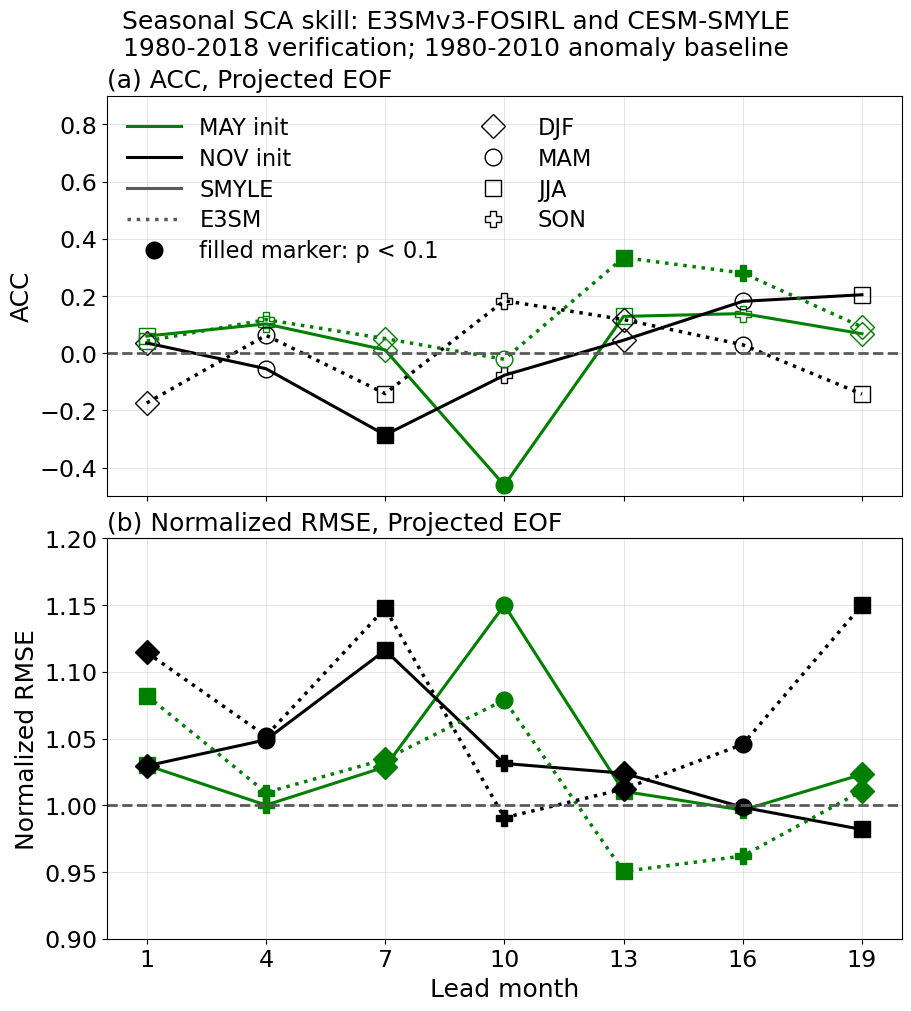

In [101]:
import matplotlib.lines as mlines

skill_plot = FIGURE_SETUP["skill"]
nmethods = len(analysis_methods)
fig, axes = plt.subplots(
    2,
    nmethods,
    figsize=(skill_plot["figsize_per_column"][0] * nmethods,
             skill_plot["figsize_per_column"][1]),
    sharex=True,
    constrained_layout=True,
    squeeze=False,
)

for col, method in enumerate(analysis_methods):
    for row, (metric, metric_label, ylim) in enumerate(metric_specs):
        ax = axes[row, col]
        panel_label = chr(ord("a") + row * nmethods + col)
        ax.set_title(
            f"({panel_label}) {metric_label}, {method_titles[method]}",
            loc="left",
            fontsize=fontz * skill_plot["panel_title_scale"],
            pad=skill_plot["title_pad"],
        )

        for model in ("SMYLE", "E3SM"):
            for init_month in init_months:
                ds = skill[model][method][init_month]
                lead_month = ds.L.values.astype(int) - 2
                target_month = np.array([
                    int(
                        model_time[model][init_month]
                        .sel(L=lead).dt.month.values[0]
                    )
                    for lead in ds.L.values
                ])
                color = skill_plot["init_colors"][init_month]
                linestyle = skill_plot["model_linestyles"][model]
                ax.plot(
                    lead_month,
                    ds[metric],
                    color=color,
                    linestyle=linestyle,
                    linewidth=skill_plot["model_linewidths"][model],
                )

                for month, marker in skill_plot["season_markers"].items():
                    season_mask = target_month == month
                    if not season_mask.any():
                        continue
                    if metric == "corr":
                        pvalues = np.asarray(ds.pval.values, dtype=float)
                        significant = (
                            season_mask
                            & np.isfinite(pvalues)
                            & (pvalues < significance_level)
                        )
                        nonsignificant = season_mask & ~significant
                        if nonsignificant.any():
                            ax.plot(
                                lead_month[nonsignificant],
                                ds[metric].values[nonsignificant],
                                color=color,
                                marker=marker,
                                markersize=skill_plot["marker_size"],
                                linestyle="none",
                                markerfacecolor="none",
                            )
                        if significant.any():
                            ax.plot(
                                lead_month[significant],
                                ds[metric].values[significant],
                                color=color,
                                marker=marker,
                                markersize=skill_plot["marker_size"],
                                linestyle="none",
                                markerfacecolor=color,
                                zorder=skill_plot["significance_zorder"],
                            )
                    else:
                        ax.plot(
                            lead_month[season_mask],
                            ds[metric].values[season_mask],
                            color=color,
                            marker=marker,
                            markersize=skill_plot["marker_size"],
                            linestyle="none",
                            markerfacecolor=color,
                        )

        ax.axhline(
            0 if metric == "corr" else 1,
            color="0.35",
            linestyle="--",
            linewidth=skill_plot["reference_linewidth"],
        )
        ax.set_xticks(lead_month_ticks)
        ax.set_xticklabels(lead_month_ticklabels)
        ax.set_xlim(*lead_month_limits)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(
            True,
            alpha=skill_plot["grid_alpha"],
            linewidth=skill_plot["grid_linewidth"],
        )
        ax.set_ylabel(
            metric_label,
            fontsize=fontz * skill_plot["axis_label_scale"],
        )
        ax.tick_params(labelsize=fontz * skill_plot["tick_label_scale"])
        if row == 1:
            ax.set_xlabel(
                "Lead month",
                fontsize=fontz * skill_plot["axis_label_scale"],
            )

init_handles = [
    mlines.Line2D(
        [], [],
        color=skill_plot["init_colors"][month],
        linewidth=skill_plot["legend_init_linewidth"],
        label=skill_plot["init_labels"][month],
    )
    for month in init_months
]
model_handles = [
    mlines.Line2D(
        [], [],
        color="0.35",
        linestyle=skill_plot["model_linestyles"][model],
        linewidth=skill_plot["model_linewidths"][model],
        label=model,
    )
    for model in ("SMYLE", "E3SM")
]
season_handles = [
    mlines.Line2D(
        [], [],
        color="black",
        marker=marker,
        markersize=skill_plot["marker_size"],
        linestyle="none",
        fillstyle="none",
        label=skill_plot["season_labels"][month],
    )
    for month, marker in skill_plot["season_markers"].items()
]
significance_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    markersize=skill_plot["marker_size"],
    linestyle="none",
    markerfacecolor="black",
    label=f"filled marker: p < {significance_level:g}",
)
axes[0, 0].legend(
    handles=init_handles + model_handles + [significance_handle] + season_handles,
    ncol=skill_plot["legend_columns"],
    fontsize=fontz * skill_plot["legend_font_scale"],
    frameon=False,
    handlelength=skill_plot["legend_handle_length"],
    columnspacing=skill_plot["legend_column_spacing"],
    labelspacing=skill_plot["legend_label_spacing"],
)

fig.suptitle(
    f"Seasonal {selected_mode} skill: E3SMv3-FOSIRL and CESM-SMYLE\n"
    f"{verification_year0}-{verification_year1} verification; "
    f"{climy0}-{climy1} anomaly baseline",
    fontsize=fontz * skill_plot["suptitle_scale"],
    linespacing=skill_plot["suptitle_linespacing"],
)
figpath = FIGURE_OUTDIR / mov.figure_filename(
    selected_mode, "skill", "e3sm", "smyle", "acc", "nrmse", "verify", verification_year0, verification_year1, "clim", climy0, climy1
)
plt.savefig(figpath, dpi=figure_dpi, bbox_inches="tight")
print(figpath)
plt.show()


## Export Compact Numeric Backup


In [102]:
summary_rows = []
for model in models:
    for method in analysis_methods:
        for init_month in init_months:
            dataset = skill[model][method][init_month]
            for lead in dataset.L.values:
                summary_rows.append(
                    {
                        "mode": selected_mode,
                        "model": model,
                        "method": method,
                        "init_month": init_month,
                        "lead": int(lead),
                        "verification_start_year": verification_year0,
                        "verification_end_year": verification_year1,
                        "anomaly_climatology_start_year": climy0,
                        "anomaly_climatology_end_year": climy1,
                        "eof_reference_start_year": eof_reference_year0,
                        "eof_reference_end_year": eof_reference_year1,
                        "acc": float(dataset["corr"].sel(L=lead)),
                        "pval": float(dataset["pval"].sel(L=lead)),
                        "nrmse": float(dataset["rmse"].sel(L=lead)),
                    }
                )

summary_df = pd.DataFrame(summary_rows)
summary_df[f"significant_p_lt_{significance_level:g}"] = (
    summary_df["pval"] < significance_level
)

if write_summary_tables:
    table_outdir.mkdir(parents=True, exist_ok=True)
    stem = (
        f"{selected_mode.lower()}_e3sm_smyle_skill_verify{verification_year0}_{verification_year1}_clim{climy0}_{climy1}"
    )
    csv_path = table_outdir / f"{stem}.csv"
    txt_path = table_outdir / f"{stem}.txt"
    summary_df.to_csv(csv_path, index=False, float_format="%.4f")
    txt_path.write_text(
        summary_df.to_string(
            index=False, float_format=lambda value: f"{value:.4f}"
        )
    )
    print(csv_path)
    print(txt_path)

summary_df.head(12)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes_variability/tables/sca_e3sm_smyle_skill_verify1980_2018_clim1980_2010.csv
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes_variability/tables/sca_e3sm_smyle_skill_verify1980_2018_clim1980_2010.txt


,mode,model,method,init_month,lead,verification_start_year,verification_end_year,anomaly_climatology_start_year,anomaly_climatology_end_year,eof_reference_start_year,eof_reference_end_year,acc,pval,nrmse,significant_p_lt_0.1
0,SCA,E3SM,eof,5,3,1980,2018,1980,2010,1980,2018,0.042617,0.799457,1.082201,False
1,SCA,E3SM,eof,5,6,1980,2018,1980,2010,1980,2018,0.117398,0.482711,1.009533,False
2,SCA,E3SM,eof,5,9,1980,2018,1980,2010,1980,2018,0.050988,0.764409,1.034452,False
3,SCA,E3SM,eof,5,12,1980,2018,1980,2010,1980,2018,-0.021249,0.902103,1.078942,False
4,SCA,E3SM,eof,5,15,1980,2018,1980,2010,1980,2018,0.334353,0.046251,0.950443,True
5,SCA,E3SM,eof,5,18,1980,2018,1980,2010,1980,2018,0.280363,0.092813,0.961968,True
6,SCA,E3SM,eof,5,21,1980,2018,1980,2010,1980,2018,0.091801,0.629473,1.010791,False
7,SCA,E3SM,eof,11,3,1980,2018,1980,2010,1980,2018,-0.174171,0.332350,1.114514,False
8,SCA,E3SM,eof,11,6,1980,2018,1980,2010,1980,2018,0.062798,0.715971,1.051894,False
9,SCA,E3SM,eof,11,9,1980,2018,1980,2010,1980,2018,-0.141245,0.397630,1.147601,False


## PCMDI EOF Pattern Diagnostics


Using atlantic map projection for SCA panels.
Missing significance diagnostics: ['ERA5 DJF', 'ERA5 MAM', 'ERA5 JJA', 'ERA5 SON', 'ERA5 DJF', 'ERA5 MAM', 'ERA5 JJA', 'ERA5 SON']
/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_sca_pcmdi_eof_patterns_e3sm_smyle_era5_y1_y2_djf_mam_jja_son.png


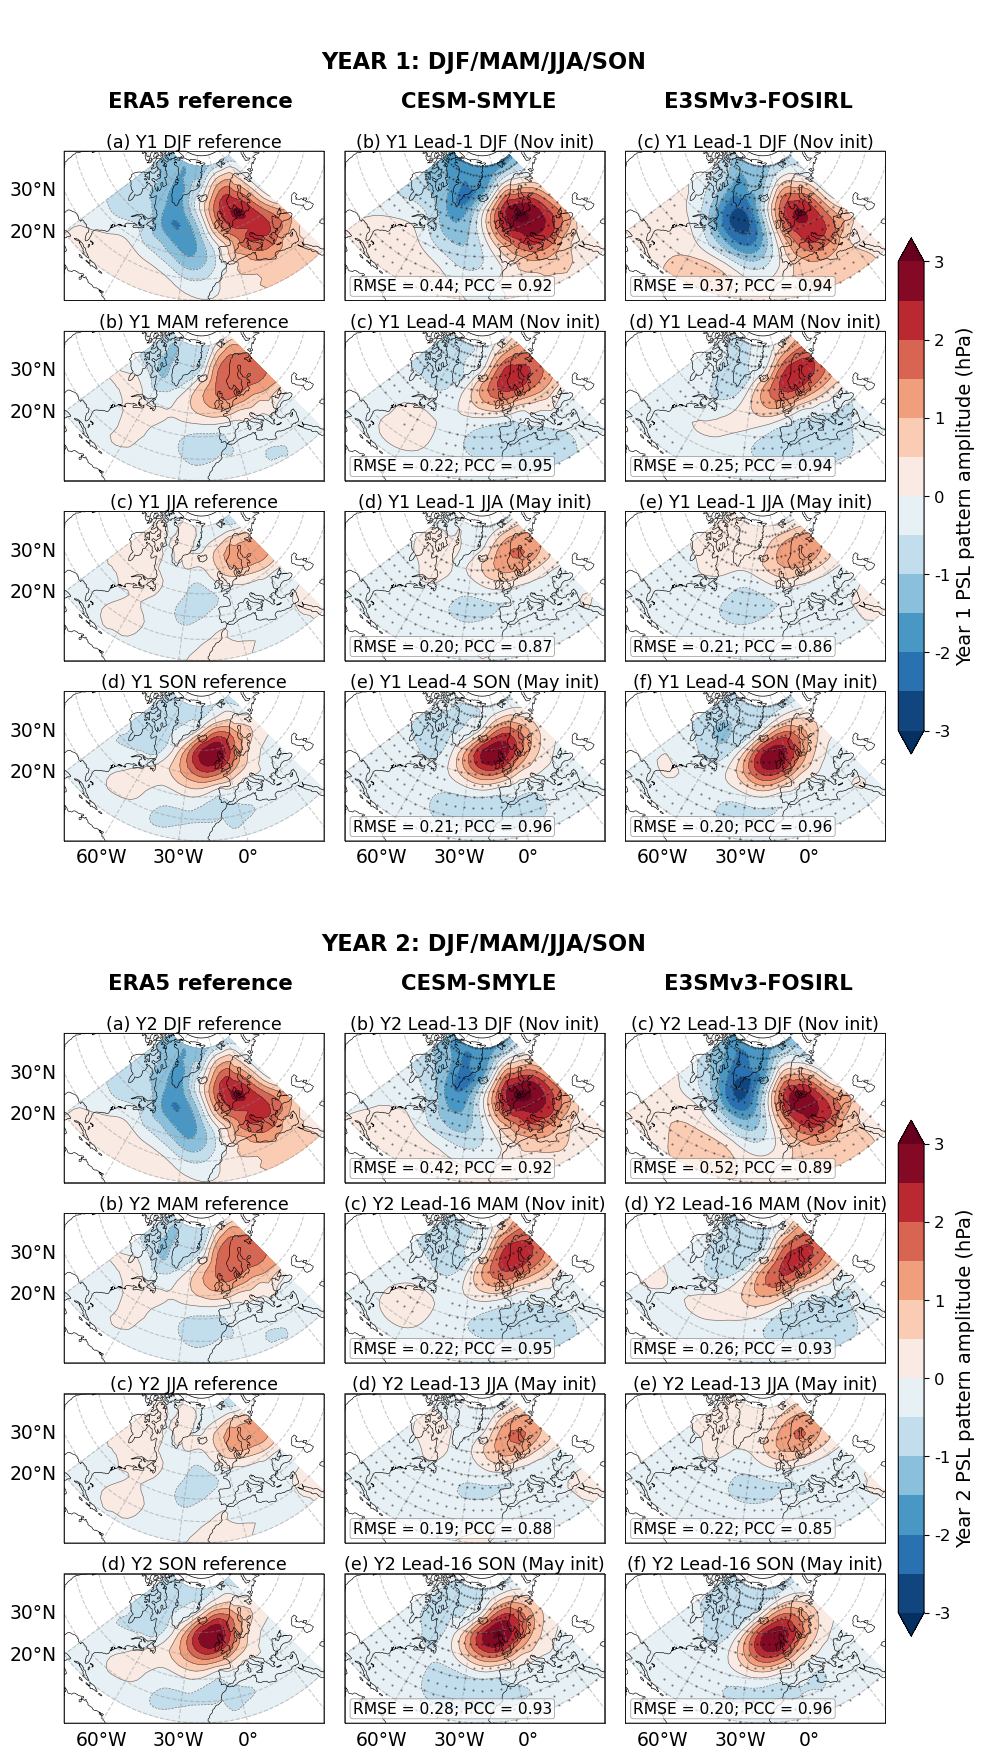

In [103]:
eof_plot = FIGURE_SETUP["eof_patterns"]

# ---------------------------------------------------------------------
# Derived font sizes for EOF-pattern figure
# ---------------------------------------------------------------------
year_section_title_fontsize = fontz * eof_plot.get("year_section_title_scale", 0.90)
column_header_fontsize = fontz * eof_plot.get("column_header_scale", 0.85)
panel_title_fontsize = fontz * eof_plot.get("panel_title_scale", 0.60)
metric_box_fontsize = fontz * eof_plot.get("metric_box_font_scale", 0.62)
map_label_fontsize = fontz * eof_plot.get("map_label_scale", 0.45)
axis_label_fontsize = fontz * eof_plot.get("axis_label_scale", 0.90)
tick_label_fontsize = fontz * eof_plot.get("tick_label_scale", 0.58)
colorbar_label_fontsize = fontz * eof_plot.get("colorbar_label_scale", 0.78)
colorbar_tick_fontsize = fontz * eof_plot.get("colorbar_tick_scale", 0.66)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
target_seasons = {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"}
model_display_names = {
    "E3SM": "E3SMv3-FOSIRL",
    "SMYLE": "CESM-SMYLE",
}
pattern_model_order = ("SMYLE", "E3SM")
column_titles = [f"{reference_product} reference"] + [
    model_display_names[model] for model in pattern_model_order
]


def build_pattern_cases():
    available = []

    for init_month in init_months:
        reference_dataset = model_datasets[pattern_model_order[0]][init_month]

        for lead_value in reference_dataset["mode_pattern"].L.values:
            lead = int(lead_value)
            display_lead = lead - 2

            target_months = {
                model: int(
                    model_datasets[model][init_month]["target_month"].sel(L=lead)
                )
                for model in pattern_model_order
            }

            if len(set(target_months.values())) != 1:
                raise ValueError(
                    f"Target-month mismatch for init {init_month:02d}, "
                    f"lead {lead}: {target_months}"
                )

            for model in pattern_model_order:
                model_leads = set(
                    map(int, model_datasets[model][init_month]["mode_pattern"].L.values)
                )
                if lead not in model_leads:
                    raise ValueError(
                        f"{model} init {init_month:02d} is missing lead {lead}"
                    )

            target_month = next(iter(target_months.values()))
            target_season = target_seasons.get(target_month, month_names[target_month])

            available.append(
                {
                    "init_month": init_month,
                    "lead": lead,
                    "display_lead": display_lead,
                    "target_year": mov.target_year_from_display_lead(display_lead),
                    "target_month": target_month,
                    "target_season": target_season,
                }
            )

    selected = []

    for target_year in eof_plot["pattern_years"]:
        for target_season in eof_plot["pattern_seasons"]:
            candidates = [
                case
                for case in available
                if case["target_year"] == target_year
                and case["target_season"] == target_season
            ]

            if not candidates:
                print(f"No pattern panel available for year {target_year} {target_season}.")
                continue

            preferred_init = eof_plot["preferred_init_by_season"].get(target_season)

            candidates = sorted(
                candidates,
                key=lambda case: (
                    case["init_month"] != preferred_init,
                    case["display_lead"],
                    case["init_month"],
                ),
            )

            selected.append(candidates[0])

    return selected


pattern_rows = []
missing_significance_panels = []
significance_sources = set()

pattern_cases = build_pattern_cases()
if not pattern_cases:
    raise ValueError("No pattern panels were selected.")

for case in pattern_cases:
    init_month = case["init_month"]
    lead = case["lead"]
    display_lead = case["display_lead"]
    target_month = case["target_month"]
    target_season = case["target_season"]
    target_year = case["target_year"]

    reference_pattern = obs_dataset["mode_pattern"].sel(target_month=target_month)

    reference_significant, significance_label = mov.pattern_significance(
        obs_dataset,
        {"target_month": target_month},
        allow_regression=False,
        eof_bootstrap_confidence=eof_bootstrap_confidence,
    )

    if significance_label:
        significance_sources.add(significance_label)

    if reference_significant is None:
        missing_significance_panels.append(f"{reference_product} {target_season}")

    panels = [
        (
            reference_pattern,
            f"Y{target_year} {target_season} reference",
            None,
            reference_significant,
        )
    ]

    for model in pattern_model_order:
        dataset = model_datasets[model][init_month]
        model_pattern = dataset["mode_pattern"].sel(L=lead)

        model_significant, significance_label = mov.pattern_significance(
            dataset,
            {"L": lead},
            allow_regression=True,
            eof_bootstrap_confidence=eof_bootstrap_confidence,
        )

        if significance_label:
            significance_sources.add(significance_label)

        if model_significant is None:
            missing_significance_panels.append(
                f"{model} init {init_month:02d} lead {display_lead}"
            )

        rmse, pcc = mov.spatial_pattern_metrics(model_pattern, reference_pattern)

        if {
            "mode_pattern_rmse_reference",
            "mode_pattern_pcc_reference",
        } <= set(dataset.data_vars):
            stored_rmse = float(dataset["mode_pattern_rmse_reference"].sel(L=lead))
            stored_pcc = float(dataset["mode_pattern_pcc_reference"].sel(L=lead))

            np.testing.assert_allclose(rmse, stored_rmse, rtol=1e-6, atol=1e-8)
            np.testing.assert_allclose(pcc, stored_pcc, rtol=1e-6, atol=1e-8)

        panels.append(
            (
                model_pattern,
                (
                    f"Y{target_year} Lead-{display_lead} {target_season} "
                    f"({month_names[init_month]} init)"
                ),
                (
                    f"RMSE = {rmse:.{eof_plot['rmse_decimals']}f}; "
                    f"PCC = {pcc:.{eof_plot['pcc_decimals']}f}"
                ),
                model_significant,
            )
        )

    pattern_rows.append(panels)


levels = np.asarray(eof_plot["levels"], dtype=float)
if levels.ndim != 1 or levels.size < 2 or not np.all(np.diff(levels) > 0):
    raise ValueError(
        "FIGURE_SETUP['eof_patterns']['levels'] must be a strictly "
        "increasing 1D sequence."
    )

reference_pattern = pattern_rows[0][0][0]
map_projection, map_projection_name = mov.make_projection(
    selected_mode,
    albers_projection_by_mode=ALBERS_PROJECTION_BY_MODE,
    use_cartopy=eof_plot.get("use_cartopy", True),
)
data_crs = mov.data_crs() if map_projection is not None else None
map_extent = mov.mode_extent(selected_mode, reference_pattern)

lon_limits = (
    float(reference_pattern.lon.min()),
    float(reference_pattern.lon.max()),
)
lon_ticks = np.linspace(lon_limits[0], lon_limits[1], 5)

subplot_kw = {"projection": map_projection} if map_projection is not None else {}

if map_projection is None and mov.CARTOPY_IMPORT_ERROR is not None:
    print(
        "Cartopy unavailable; using plain latitude-longitude axes:",
        mov.CARTOPY_IMPORT_ERROR,
    )
elif map_projection_name is not None:
    print(f"Using {map_projection_name} map projection for {selected_mode} panels.")


display_row_by_pattern_row = {}
header_display_row_by_year = {}
height_ratios = [eof_plot["top_section_gap_ratio"]]

display_row = 1
previous_year = None

for row in range(len(pattern_rows)):
    target_year = pattern_cases[row]["target_year"]

    if target_year != previous_year:
        if previous_year is not None:
            height_ratios.append(eof_plot["year_section_gap_ratio"])
            display_row += 1

        header_display_row_by_year[target_year] = display_row
        height_ratios.append(eof_plot["year_section_header_ratio"])
        display_row += 1
        previous_year = target_year

    display_row_by_pattern_row[row] = display_row
    height_ratios.append(1.0)
    display_row += 1

plot_display_rows = set(display_row_by_pattern_row.values())
display_nrows = len(height_ratios)

fig, axes = plt.subplots(
    display_nrows,
    len(column_titles),
    figsize=(
        eof_plot["figsize_width"],
        eof_plot["figsize_row_height"] * sum(height_ratios),
    ),
    constrained_layout=False,
    sharex=True,
    sharey=True,
    squeeze=False,
    subplot_kw=subplot_kw,
    gridspec_kw={"height_ratios": height_ratios},
)

fig.subplots_adjust(
    left=eof_plot.get("subplot_left", 0.045),
    right=eof_plot.get("subplot_right", 0.915),
    bottom=eof_plot.get("subplot_bottom", 0.035),
    top=eof_plot.get("subplot_top", 0.975),
    wspace=eof_plot.get("subplot_wspace", 0.08),
    hspace=eof_plot.get("subplot_hspace", 0.20),
)

for display_row in range(display_nrows):
    if display_row in plot_display_rows:
        continue
    for col in range(len(column_titles)):
        axes[display_row, col].set_axis_off()

plot_axes = axes[list(display_row_by_pattern_row.values()), :]

# ---------------------------------------------------------------------
# Compute column centers from actual plotted map axes.
# This gives better alignment than using hidden header axes.
# ---------------------------------------------------------------------
#column_centers = [
#    (plot_axes[0, col].get_position().x0 +
#     plot_axes[0, col].get_position().x1) / 2
#    for col in range(plot_axes.shape[1])
#]
column_centers = []
for col in range(plot_axes.shape[1]):
    x0 = min(ax.get_position().x0 for ax in plot_axes[:, col])
    x1 = max(ax.get_position().x1 for ax in plot_axes[:, col])
    center = (x0 + x1) / 2
    center -= col * 0.015
    column_centers.append(center)

header_axes = {
    target_year: axes[display_row, :]
    for target_year, display_row in header_display_row_by_year.items()
}

section_last_rows = {
    max(
        row
        for row, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    )
    for target_year in eof_plot["pattern_years"]
    if any(case["target_year"] == target_year for case in pattern_cases)
}


# ---------------------------------------------------------------------
# Year-section titles and column headers
# ---------------------------------------------------------------------
for target_year in eof_plot["pattern_years"]:
    rows = [
        row
        for row, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    ]

    if not rows:
        continue

    section_season_label = "/".join(
        pattern_cases[row]["target_season"] for row in rows
    )

    header_pos = header_axes[target_year][1].get_position()
    header_center_y = header_pos.y0 + 0.50 * header_pos.height

    year_title_y = header_pos.y0 + 0.72 * header_pos.height
    column_title_y = header_pos.y0 + 0.25 * header_pos.height

    fig.text(
        0.5,
        year_title_y,
        f"YEAR {target_year}: {section_season_label}",
        ha="center",
        va="center",
        fontsize=year_section_title_fontsize,
        fontweight="bold",
    )

    for col, column_title in enumerate(column_titles):
        fig.text(
            column_centers[col],
            column_title_y,
            column_title,
            ha="center",
            va="center",
            fontsize=column_header_fontsize,
            fontweight="bold",
        )


images_by_year = {}
# Build row number within each year section
year_row_index = {}
for target_year in eof_plot["pattern_years"]:
    rows_in_year = [
        r
        for r, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    ]
    for local_row, global_row in enumerate(rows_in_year):
        year_row_index[global_row] = local_row

# Plot panels and collect images for shared colorbars
for row, panels in enumerate(pattern_rows):
    row_year = pattern_cases[row]["target_year"]

    for col, (pattern, title, metrics_text, significant) in enumerate(panels):
        local_row = year_row_index[row]
        panel_label = chr(
            ord("a") + local_row * nmethods + col
        )
        plot_pattern = mov.add_cyclic_longitude_for_plot(pattern)

        if map_projection is not None:
            mov.apply_polar_circular_boundary(
                plot_axes[row, col],
                map_projection_name,
                enabled=eof_plot.get("polar_circular_boundary", True),
            )

        image = plot_axes[row, col].contourf(
            plot_pattern.lon,
            plot_pattern.lat,
            plot_pattern,
            levels=levels,
            cmap="RdBu_r",
            extend="both",
            transform=data_crs,
        )

        if eof_plot["draw_contour_lines"]:
            plot_axes[row, col].contour(
                plot_pattern.lon,
                plot_pattern.lat,
                plot_pattern,
                levels=eof_plot["contour_line_levels"],
                colors=eof_plot["contour_line_color"],
                linewidths=eof_plot["contour_linewidth"],
                alpha=eof_plot["contour_line_alpha"],
                transform=data_crs,
            )

        images_by_year[row_year] = image

        if significant is not None:
            plot_significant = mov.add_cyclic_longitude_for_plot(significant)
            stipple = plot_significant.isel(
                lat=slice(None, None, eof_plot["stipple_stride"]),
                lon=slice(None, None, eof_plot["stipple_stride"]),
            )
            stipple_lon, stipple_lat = np.meshgrid(stipple.lon, stipple.lat)

            plot_axes[row, col].scatter(
                stipple_lon[stipple.values],
                stipple_lat[stipple.values],
                s=eof_plot["stipple_size"],
                color=eof_plot["stipple_color"],
                alpha=eof_plot["stipple_alpha"],
                marker=".",
                linewidths=0,
                zorder=eof_plot["stipple_zorder"],
                transform=data_crs,
            )

        if map_projection is not None:
            mov.set_extent(
                plot_axes[row, col],
                map_projection_name,
                map_extent,
                data_crs,
            )
            mov.add_map_features(
                plot_axes[row, col],
                map_projection_name,
                eof_plot,
            )
            
            if map_projection_name in {"north_pacific", "atlantic"}:
                ax = plot_axes[row, col]

                # Remove rectangular GeoAxes frame/box
                ax.set_frame_on(True)

                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_linewidth(0.5)
            
            mov.configure_gridlines(
                plot_axes[row, col],
                mode=selected_mode,
                projection_name=map_projection_name,
                row=row,
                col=col,
                section_last_rows=section_last_rows,
                extent=map_extent,
                data_projection=data_crs,
                settings=eof_plot,
                fontsize=map_label_fontsize,
            )
        else:
            plot_axes[row, col].set_xlim(*lon_limits)
            plot_axes[row, col].set_xticks(lon_ticks)
        
        plot_axes[row, col].set_title(
            f"({panel_label}) {title}",
            fontsize=panel_title_fontsize,
            pad=eof_plot["panel_title_pad"],
            linespacing=eof_plot["panel_title_linespacing"],
        )

        if metrics_text is not None:
            plot_axes[row, col].text(
                eof_plot["metric_box_x"],
                eof_plot["metric_box_y"],
                metrics_text,
                transform=plot_axes[row, col].transAxes,
                ha="left",
                va="bottom",
                fontsize=metric_box_fontsize,
                zorder=eof_plot["metric_box_zorder"],
                bbox={
                    "boxstyle": f"round,pad={eof_plot['metric_box_pad']}",
                    "facecolor": "white",
                    "edgecolor": "0.35",
                    "linewidth": eof_plot["metric_box_linewidth"],
                    "alpha": eof_plot["metric_box_alpha"],
                },
            )

        if row == len(pattern_rows) - 1:
            plot_axes[row, col].set_xlabel(
                "Longitude",
                fontsize=axis_label_fontsize,
            )

        plot_axes[row, col].tick_params(labelsize=tick_label_fontsize)

        if map_projection is None:
            plot_axes[row, col].grid(alpha=eof_plot["grid_alpha"])

        if col == 0 and map_projection is None:
            plot_axes[row, col].set_ylabel(
                "Latitude",
                fontsize=axis_label_fontsize,
            )


for target_year in eof_plot["pattern_years"]:
    rows = [
        row
        for row, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    ]

    if not rows:
        continue

    colorbar = fig.colorbar(
        images_by_year[target_year],
        ax=plot_axes[rows, :].ravel().tolist(),
        ticks=levels[::2],
        shrink=eof_plot["colorbar_shrink"],
        pad=eof_plot["colorbar_pad"],
        fraction=eof_plot["colorbar_fraction"],
    )
    colorbar.set_label(
        f"Year {target_year} {source_field} pattern amplitude ({field_units})",
        fontsize=colorbar_label_fontsize,
    )
    colorbar.ax.tick_params(labelsize=colorbar_tick_fontsize)
    colorbar.ax.set_yticklabels([f"{level:g}" for level in levels[::2]])


year_label = "-".join(f"Y{year}" for year in eof_plot["pattern_years"])
season_label = "/".join(eof_plot["pattern_seasons"])

if missing_significance_panels:
    print("Missing significance diagnostics:", missing_significance_panels)

figpath = FIGURE_OUTDIR / mov.figure_filename(
    selected_mode,
    "pcmdi",
    "eof_patterns",
    "e3sm",
    "smyle",
    reference_product,
    year_label,
    season_label,
)

plt.savefig(figpath, dpi=figure_dpi, bbox_inches="tight")
print(figpath)
plt.show()

In [104]:
print(
    f"{selected_mode} analysis complete. Processed-data directory:",
    index_cache_dir,
)

SCA analysis complete. Processed-data directory: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes_variability/modes/sca/indices
